# E-Commerce Business Performance Analysis
## Project Objective
This project analyses the Olist Brazilian E-Commerce dataset to understand sales performance,customer behaviour,delivery efficiency,and business trends using python and pandas.

## TOOLS USED.
 - python
 - Pandas
 - Matplotlib
 - Jupyter Notebook
 - Power BI
 
## DATASET.
Brazilian E-commerce Public Dataset by Olist(Kaggle).

In [1]:
import pandas as pd
orders = pd.read_csv("olist_orders_dataset.csv")

In [2]:
# Understanding the structure of the dataset
print(orders.head())

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08

In [3]:
print(orders.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None


In [4]:
# Number of Records
print(orders.shape)

(99441, 8)


In [5]:
print(orders.index)

RangeIndex(start=0, stop=99441, step=1)


In [6]:
# Order Status Analysis
#The objective of this analysis is to understand how customer orders are distributed
#across different stages of the order fulfilement process
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [7]:
orders["order_status"].value_counts(normalize=True)*100

order_status
delivered      97.020344
shipped         1.113223
canceled        0.628513
unavailable     0.612423
invoiced        0.315765
processing      0.302692
created         0.005028
approved        0.002011
Name: proportion, dtype: float64

## FINDINGS.

- Total Orders:99,441
- Delivered orders: 97.02%
- Cancelled Order : 063%.
 The high delivery rate indicates strong operational performance.


In [8]:
orders["order_purchase_timestamp"]=pd.to_datetime(orders["order_purchase_timestamp"])

In [9]:
orders["order_purchase_timestamp"].head()

0   2017-10-02 10:56:33
1   2018-07-24 20:41:37
2   2018-08-08 08:38:49
3   2017-11-18 19:28:06
4   2018-02-13 21:18:39
Name: order_purchase_timestamp, dtype: datetime64[ns]

In [10]:
orders["year_month"]=orders["order_purchase_timestamp"].dt.to_period('M')

In [11]:
monthly_orders=orders.groupby("year_month").size()

In [12]:
# FINDING THE BUSIEST MONTH(the top ten months with the highest number of orders)
monthly_orders.sort_values(ascending=False).head(10)

year_month
2017-11    7544
2018-01    7269
2018-03    7211
2018-04    6939
2018-05    6873
2018-02    6728
2018-08    6512
2018-07    6292
2018-06    6167
2017-12    5673
Freq: M, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

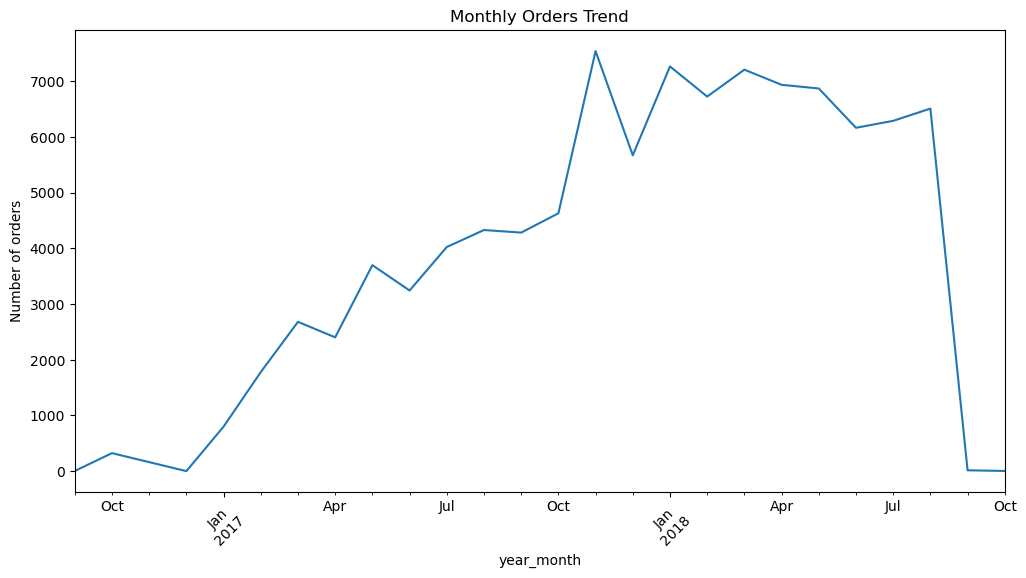

In [13]:
import matplotlib.pyplot as plt
monthly_orders.plot(figsize=(12,6))

plt.title("Monthly Orders Trend")
plt.xlabel("year_month")
plt.ylabel("Number of orders")
plt.xticks(rotation=45)
plt.show

# SECTION 4:DATA CLEANING
## Business Question
Is the dtaset clean enough fot data analysis ???
## Why is it important
Poor quality data leads to incorrect business decisions.Before analysing sales,we need to identify missing values,duplicate records,and incorrect data types

In [14]:
#Total count of missing values column wise
orders.isnull().sum()


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
year_month                          0
dtype: int64

In [15]:
orders.duplicated().sum()

np.int64(0)

In [16]:
orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                        object
order_delivered_carrier_date             object
order_delivered_customer_date            object
order_estimated_delivery_date            object
year_month                            period[M]
dtype: object

In [17]:
date_columns = ["order_approved_at","order_delivered_carrier_date","order_delivered_customer_date","order_estimated_delivery_date"]

for column in date_columns:orders[column]=pd.to_datetime(orders[column])

In [18]:
orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
year_month                            period[M]
dtype: object

In [19]:
missing_values=pd.DataFrame({"column":orders.columns,"Missing Values":orders.isnull().sum().values,"Percentage":(orders.isnull().sum()/len(orders)*100).round(2)})

# Business Insight

The dataset contains missing values in some delivery related columns.

This is expected because:
-cancelled orders do not have deliverty dates
-Orders that were not delivered may not have carrier information.

Therefore,these missing values should be investigated before deciding whether to remove or retain them

In [20]:
# LOADING ORDER_ITEM DATASET

order_items = pd.read_csv("olist_order_items_dataset.csv")

In [21]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [22]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [23]:
order_items.shape

(112650, 7)

In [24]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [25]:
order_items.duplicated().sum()

np.int64(0)

# Business Insight
The order_items dataset is clean and complete
-No missing values were found
-No duplicate records were found

This indicates that the dataset is reliable for revenue,pricing,freight cost,and  product analysis

# SECTION 5: DATA INTEGRATION.
## Business Insight
How can we combine order information wuith product and pricing information to perform business analysis ?

## Why is important
Business data is often stored acrossed multiple tables Merging dataset allows us to analyze revenue,product,customers behaviour,and operational performance from a single dataset.

In [26]:
# merging the datasets
sales = pd.merge(orders,order_items,on="order_id",how="inner")

In [27]:
sales.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year_month,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [28]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 15 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112650 non-null  object        
 1   customer_id                    112650 non-null  object        
 2   order_status                   112650 non-null  object        
 3   order_purchase_timestamp       112650 non-null  datetime64[ns]
 4   order_approved_at              112635 non-null  datetime64[ns]
 5   order_delivered_carrier_date   111456 non-null  datetime64[ns]
 6   order_delivered_customer_date  110196 non-null  datetime64[ns]
 7   order_estimated_delivery_date  112650 non-null  datetime64[ns]
 8   year_month                     112650 non-null  period[M]     
 9   order_item_id                  112650 non-null  int64         
 10  product_id                     112650 non-null  object        
 11  

In [29]:
sales.shape

(112650, 15)

# SECTION 6: SALES ANALYSIS

## Business Question
How much revenue did the company generate?
## Why is it important
Revenue is one of the most important key performance indicators (KPIs).It helps management evaluate business performance and make strategic decisions.


In [30]:
## KPI 1:TOTAL REVENUE
total_revenue = sales["price"].sum()
print(f"Total Revenue:{total_revenue: ,.2f}")

Total Revenue: 13,591,643.70


In [31]:
# KPI 2: TOTAL FREIGHT REVENUE
total_freight = sales["freight_value"].sum()

print(f"Total Freight Revenue:{total_freight: ,.2f}")

Total Freight Revenue: 2,251,909.54


In [32]:
# KPI 3: AVERAGE PRODUCT PRICE
average_price =sales["price"].mean()

print(f"Average Product Price:{average_price:.2f}")


Average Product Price:120.65


In [33]:
# KPI 4: AVERAGE FREIGHT COST
average_freight = sales["freight_value"].mean()

print(f"Average Freight Cost:{average_freight: ,.2f}")

Average Freight Cost: 19.99


## BUSINESS INSIGHT
- The company generates a total product revenue of 13,591,643.70.
- Shipping charges contributed an additional 2,251,909.54
- The average product price is 120.65.
- The average freight cost is 19.99.

## Management Interpretation
The company generated strong revenue while maintaining relatively low shipping costs compared to product prices. This indicates efficient logistics and healthy pricing performance.

In [34]:
# TOP SELLING PRODUCTS
top_products = sales.groupby("product_id")["price"].sum()

top_products =top_products.sort_values(ascending=False)

top_products.head(10)

product_id
bb50f2e236e5eea0100680137654686c    63885.00
6cdd53843498f92890544667809f1595    54730.20
d6160fb7873f184099d9bc95e30376af    48899.34
d1c427060a0f73f6b889a5c7c61f2ac4    47214.51
99a4788cb24856965c36a24e339b6058    43025.56
3dd2a17168ec895c781a9191c1e95ad7    41082.60
25c38557cf793876c5abdd5931f922db    38907.32
5f504b3a1c75b73d6151be81eb05bdc9    37733.90
53b36df67ebb7c41585e8d54d6772e08    37683.42
aca2eb7d00ea1a7b8ebd4e68314663af    37608.90
Name: price, dtype: float64

# Business insight
- The analysis identified the top 10 revenue-generating products.
- The highest-selling product generated a total revenue of 63,885.00.

These products contribute significantly to overall company revenue and should receive priority uin inventory planning, marketing campaigns,and supply chain Management.

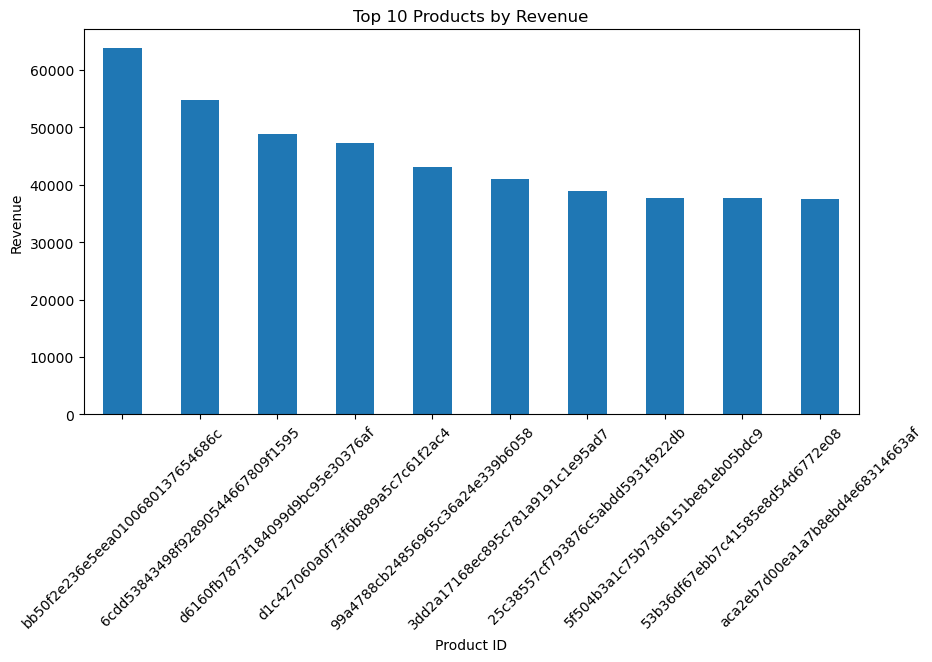

In [35]:
import matplotlib.pyplot as plt

top_products.head(10).plot(kind="bar",figsize=(10,5))

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product ID")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()


# BUSINESS INSIGHT
The bar chart shows the ten highest revenue-generating products.

The highest-performing product generated over 63,000 in revenue, while the remaining top products generated between approximately 34,000 and 55,000.

## RECOMMENDATION

Ensure these products remain in stock.
Prioritize them in marketing campaigns
Monitor demand to avoid stock shortages
Investigate why these products outperform others and apply those insights to similar products

In [36]:
# SECTION 8: TOP SELLERS

top_sellers = sales.groupby("seller_id")["price"].sum()

top_seller = top_sellers.sort_values(ascending=False)
top_seller.head(10)

seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    229472.63
53243585a1d6dc2643021fd1853d8905    222776.05
4a3ca9315b744ce9f8e9374361493884    200472.92
fa1c13f2614d7b5c4749cbc52fecda94    194042.03
7c67e1448b00f6e969d365cea6b010ab    187923.89
7e93a43ef30c4f03f38b393420bc753a    176431.87
da8622b14eb17ae2831f4ac5b9dab84a    160236.57
7a67c85e85bb2ce8582c35f2203ad736    141745.53
1025f0e2d44d7041d6cf58b6550e0bfa    138968.55
955fee9216a65b617aa5c0531780ce60    135171.70
Name: price, dtype: float64

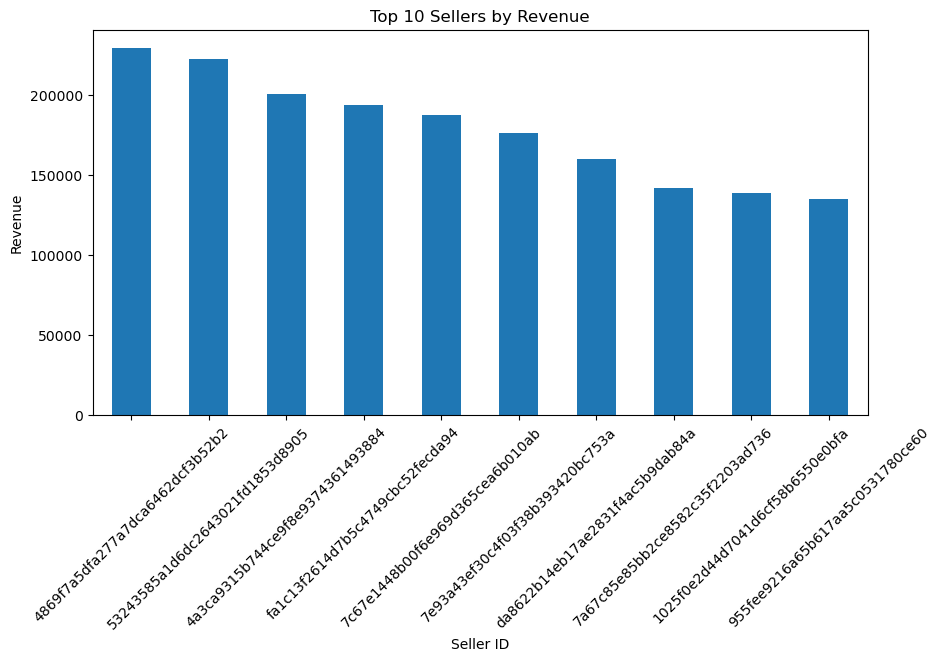

In [37]:
top_seller.head(10).plot(kind="bar",figsize=(10,5))

plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Seller ID")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

## BUSINESS INSIGHT
The top seller generated significantly higher revenue than the remaining sellers.

### RECOMMENDATION
Retain top-performing sellers throught incentives.
Analyse their pricing and product strategies.
Help Lower-performing seller improve through training and promotional support.


In [38]:
# SECTION 9: MONTHLY REVENUE ANALYSIS

monthly_revenue = sales.groupby("year_month")["price"].sum()

monthly_revenue = monthly_revenue.sort_values(ascending=False)
monthly_revenue.head(10)

year_month
2017-11    1010271.37
2018-04     996647.75
2018-05     996517.68
2018-03     983213.44
2018-01     950030.36
2018-07     895507.22
2018-06     865124.31
2018-08     854686.33
2018-02     844178.71
2017-12     743914.17
Freq: M, Name: price, dtype: float64

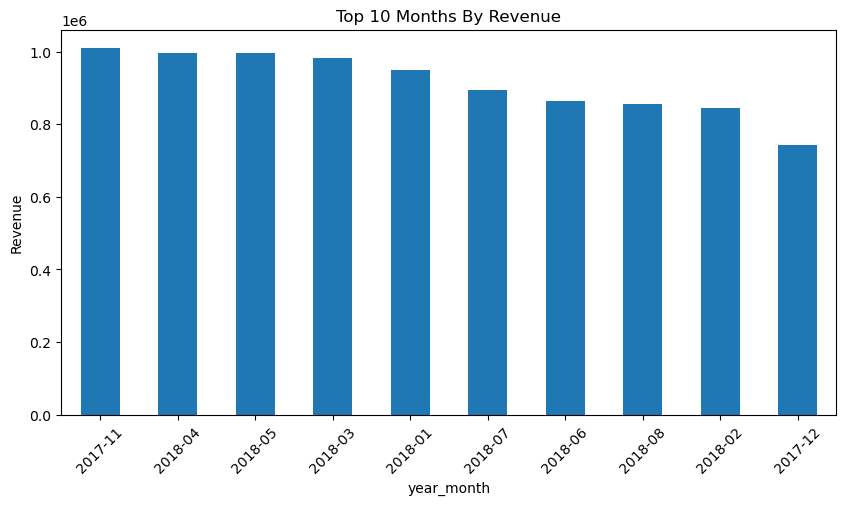

In [39]:
monthly_revenue.head(10).plot(kind="bar",figsize=(10,5))

plt.title("Top 10 Months By Revenue")
plt.xlabel("year_month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

## BUSINESS INSIGHT
The monthly revenue analysis shows that revenue varies differntly across each months
## KEY FINDINGS

November 2017 records the highest revenue.
Revenue remained consistently strong throughout 2018
Some months experienced lower revenue,indicating possible seasonal demand.
## BUSINESS RECOMMENDATIONS

Increase inventory before high-revenue months.
Lauch promotional campaigns before peak periods.
Investigate factors behind lower-performing months to improve future sales


In [40]:
# SECTION 10: AVERAGE ORDER VALUE(AOV)\

average_order_value =sales.groupby("order_id")["price"].sum().mean()

print(f"Average Order Value:{average_order_value: .2f}")

Average Order Value: 137.75


## BUSINESS INSIGHT

The Average Order Value measures the average amount customers spend per order.

## Business Importance

A higher AOV indicates customer are spending more per purchase.
Business can increase AOV throuhg product bundles,cross-selling,and upselling.


In [41]:
## SECTION 11: CUSTOMER PURCHASE FREQUENCY

customer_orders = sales.groupby("customer_id")["order_id"].nunique()

customer_orders.describe()

count    98666.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: order_id, dtype: float64

In [42]:
top_customers = customer_orders.sort_values(ascending=False)
top_customers.head(10)

customer_id
00012a2ce6f8dcda20d059ce98491703    1
aa33d697a2f5ee04aae5e9a8227e913e    1
aa5f8aa4c21fe89a04e8d221d4cd8ac1    1
aa5f87b79875f43b90b310decb62356e    1
aa5f5931b8901ae1ca4b8302f9b94c02    1
aa5e99afaf6a4dce3da0dee9f41beac8    1
aa5e567592c7fce76e3937e35c6a4ecb    1
aa5e341090958e5111abe3ba75bcfe87    1
aa5e0a0c36015d39de864189a2b00b09    1
aa5dfb0872b3828aa250acb54d387266    1
Name: order_id, dtype: int64

## BUSINESS INSIGHT
Customer purchase frequency measures how often customers place orders.The analysis shows that every customer_id is associated with only one order in this dataset.

### BUSINESS IMPORTANCE
 - Repeat customers are valueable because they increase customer lifetime value and long-term revenue.
 - Businesses should reward loyal customers through loyalty programmes and personalised offers.
 - Encourageing repeat purchases can significantly improve long-term profitability.

## BUSINESS INTERPRETATION
This analysis suggest that the dataset assigns a unique customer_id to each order rather than tracking repeat customer over time.

Therefore,customer loyalty and repeat purchase behaviour cannot be accurately analysed using "customers_id" alone

## BUSINESS RECOMMENDATION

To analyse customer retention and repeat purchases, a persistent customer identifier would be required.

## SECTION 12: SHIPPING COST ANALYSIS

# Business Question
Which product generate the highest shipping cost ?
# Why is it important
 Shipping cost is one of the largest operational expenses in e-commerce.

 understanding which products incur the highest freight costs helps businesses optimise logistics,negotiate better shipping rates,and improve profitability

In [43]:
top_freight =sales.groupby("product_id")["freight_value"].sum()

top_freight =top_freight.sort_values(ascending=False)

top_freight.head(10)

product_id
d1c427060a0f73f6b889a5c7c61f2ac4    13761.52
99a4788cb24856965c36a24e339b6058     8046.04
422879e10f46682990de24d770e7f83d     7624.04
389d119b48cf3043d311335e499d9c6b     7242.09
aca2eb7d00ea1a7b8ebd4e68314663af     7211.86
3dd2a17168ec895c781a9191c1e95ad7     7129.62
368c6c730842d78016ad823897a372db     6927.60
53759a2ecddad2bb87a079a1f1519f73     6881.03
c4baedd846ed09b85f78a781b522f126     5961.09
8c591ab0ca519558779df02023177f44     5517.22
Name: freight_value, dtype: float64

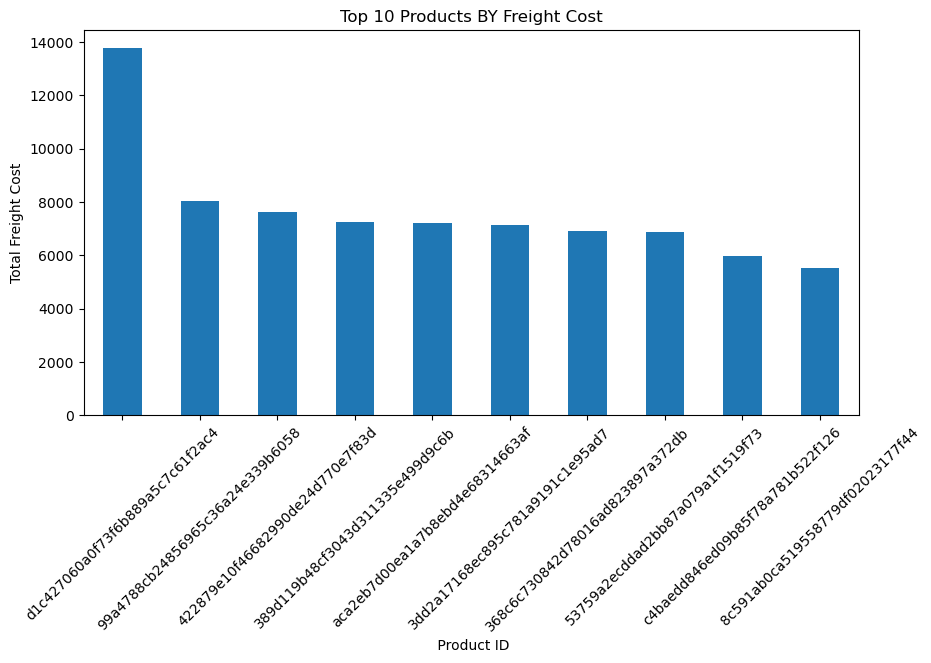

In [44]:
import matplotlib.pyplot as plt

top_freight.head(10).plot(kind="bar",figsize=(10,5))

plt.title("Top 10 Products BY Freight Cost")
plt.xlabel(" Product ID")
plt.ylabel("Total Freight Cost")
plt.xticks(rotation=45)

plt.show()

## Business insight
 Some products contribute dispropotionately to shipping costs.
These products may be heavy,bulky,or shipped over long distances,resulting in higher logistics expenses.

 ## Business Recommendation
- Negotiate better freight rates with logistics partners
- Store high- demand products closer to customers.
- Optimise packaing to reduce shipping costs.
- Review products with consistenly high freight expenses

In [45]:
## SECTION 13: CORRELATION ANALYSIS


In [46]:
correlation = sales["price"].corr(sales["freight_value"])

print(f"correlation between price and Freight Cost: {correlation: .2f}")

correlation between price and Freight Cost:  0.41


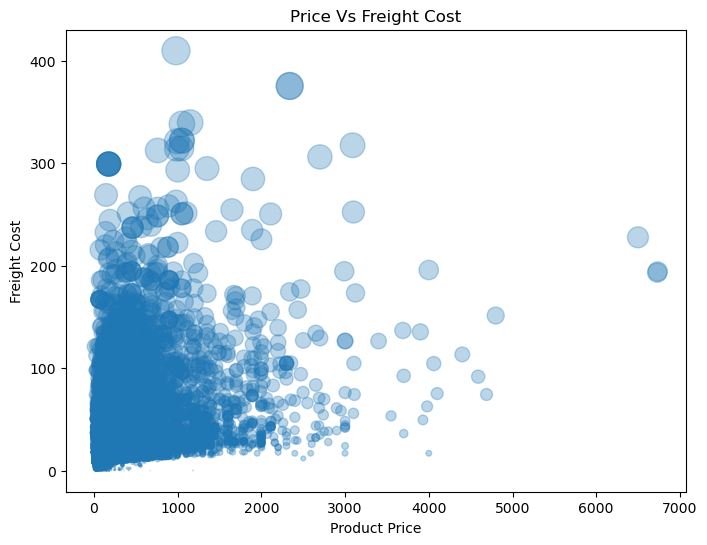

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(sales["price"],sales["freight_value"],sales["freight_value"],alpha=0.30)

plt.title("Price Vs Freight Cost")
plt.xlabel("Product Price")
plt.ylabel("Freight Cost")

plt.show()

## BUSINESS INSIGHT

The correlation coefficient betweent product price and freight cost is 0.41,indicating a moderate positive relationship.Higher-priced peroducts generally have higher shipping costs,but price alone does not determine freight cost.
## BUSINESS IMPORTANCE

Freight expenses are influenced by several factors,including package size,shipping distance,and logistics methods.Businesses should consider these factors when planning pricing and shipping strategy.

## BUSINESS RECOMMENDATION

- Optimize packaging to reduce shipping costs.
- Negotiate better shipping rates with logistics partners.
- Review products with unusually high freight costs.
- Improve warehouse location to reduce delivery distances.

## SECTION 14: EXECUTIVE SALES DASGBOARD

## Business Question

How can management view the company's key performance indicators and trend in one place ?

## Why is it important ?

An executive dashboard summarises business performance using KPIs and charts, alowing managers to make quick, informed decisions.

In [48]:
import matplotlib.pyplot as plt

In [62]:
total_revenue = sales["price"].sum()
total_freight = sales["freight_value"].sum()
average_price =sales["price"].mean()
average_order_value = sales.groupby("order_id")["price"].sum().mean()

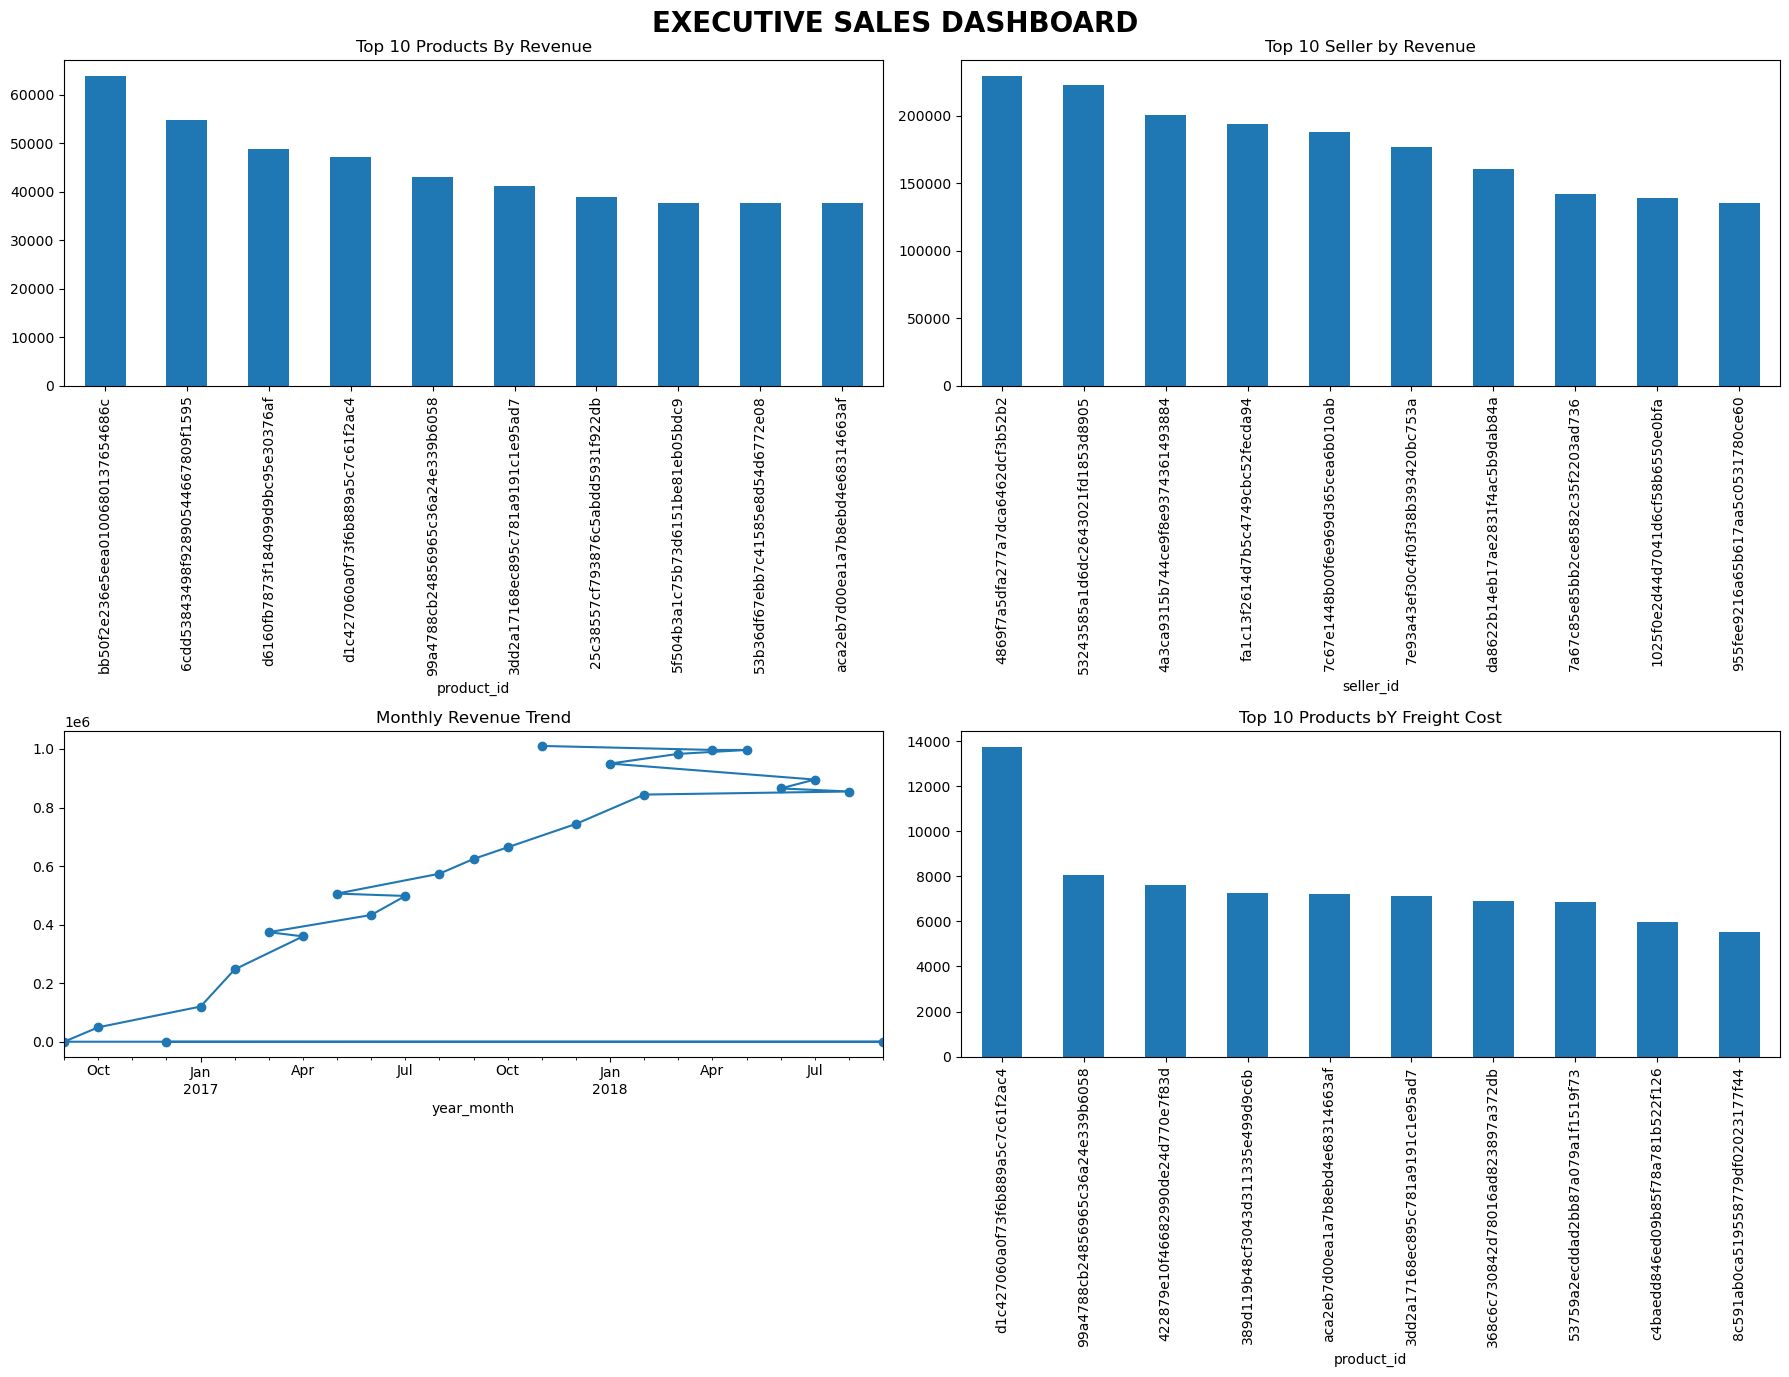

In [77]:
fig,axes = plt.subplots(2,2,figsize=(18,14))

fig.suptitle("EXECUTIVE SALES DASHBOARD",fontsize=20,fontweight="bold")

top_products.head(10).plot(kind="bar",ax=axes[0,0])
axes[0,0].set_title("Top 10 Products By Revenue")

top_seller.head(10).plot(kind="bar",ax=axes[0,1])
axes[0,1].set_title("Top 10 Seller by Revenue")

monthly_revenue.plot(kind="line",marker="o",ax=axes[1,0])
axes[1,0].set_title("Monthly Revenue Trend")

    
top_freight.head(10).plot(kind="bar",ax=axes[1,1])
axes[1,1].set_title("Top 10 Products bY Freight Cost")

plt.tight_layout()
plt.show()

# Project Summary
## Objective
Analyse sales performance using the Brazilian E-Commerce(Olist) dataset.
  
## Key KPIs
- Total Revenue
- Total Freight Revenue
- Average Product Price
- Average Freight Cost
- Average Order Value

  ## Key Insights
  - Revenue peaks suring specific months,indicating seasonality.
  - A small number of products generate a large share of total revenue.
  - Freight costs show a moderate positive prices.
  - Certain sellers contribute significantly more revenue than others

  ## Recommendtion
  - Increase Inventory before peak sales periods.
  - Strenghten relationship with high-performing sellers.
  - Review products with high freight costs to improve logistics efficiency.
  - Focus marketing efforts on top_performing products. 